In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/ethiopia.csv")
df["Country"] = "Ethiopia"
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month
df = df.replace(-999, np.nan)
df.duplicated().sum()
df = df.drop_duplicates()
df.describe()



,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.069326,23.200256,10.228651,12.971604,3.639413,68.435034,1.982522,3.579688,77.040721,9.702093,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.030000,16.160000,1.170000,4.100000,0.000000,14.420000,0.460000,0.790000,76.690000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.820000,21.110000,8.417500,9.817500,0.020000,59.080000,1.410000,2.730000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.050000,22.740000,10.985000,13.045000,0.820000,71.185000,1.970000,3.540000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.360000,25.180000,12.230000,16.022500,4.582500,80.790000,2.480000,4.380000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.530000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.896631,2.748820,2.608968,3.823060,6.303272,14.720017,0.689174,1.123225,0.088258,2.363322,NaN,3.477046


Descriptive Statistics Interpretation (Ethiopia Dataset)

The summary statistics provide an overview of the climate conditions in Ethiopia from 2015 to 2026 based on NASA POWER data.

 Temperature (T2M, T2M_MAX, T2M_MIN)
The mean daily temperature (T2M) is approximately 16.07°C, indicating a generally mild climate.
Maximum recorded temperature reaches 30.93°C, showing occasional heat extremes.
Minimum temperature drops to 1.17°C, indicating cold periods, likely in high-altitude regions.
The standard deviation shows moderate variability, meaning temperature changes are relatively stable over time.

 Insight: Ethiopia has a moderate but variable temperature climate influenced by seasonal and altitude differences.

 Precipitation (PRECTOTCORR)
Average rainfall is 3.64 mm/day, indicating moderate precipitation overall.
Maximum rainfall reaches 82.3 mm/day, showing occasional heavy rainfall events.
The high standard deviation suggests rainfall is highly variable and seasonal.

 Insight: Rainfall in Ethiopia is not evenly distributed and shows strong seasonal patterns with occasional extreme rainfall events.

 Humidity (RH2M)
Mean relative humidity is 68.4%, indicating generally humid conditions.
Values range from 14% to 92%, showing strong seasonal fluctuations.

 Insight: Humidity levels vary significantly, likely driven by seasonal rainfall cycles.

 Wind Speed (WS2M)
Average wind speed is 1.98 m/s, indicating generally low to moderate wind conditions.
Maximum wind speed reaches 4.13 m/s, with rare strong wind events.

👉 Insight: Wind conditions are relatively stable with limited extreme wind activity.

📈 Atmospheric Pressure (PS)
Atmospheric pressure is extremely stable with very low variation.
Mean pressure is around 77 kPa, with minimal deviation.

👉 Insight: Pressure is not a major variable affecting climate variability in this dataset.

📅 Overall Conclusion

The Ethiopian climate dataset shows:

Moderate temperature with seasonal variation
Highly variable rainfall patterns
Stable wind and pressure conditions
Strong seasonal climate behavior

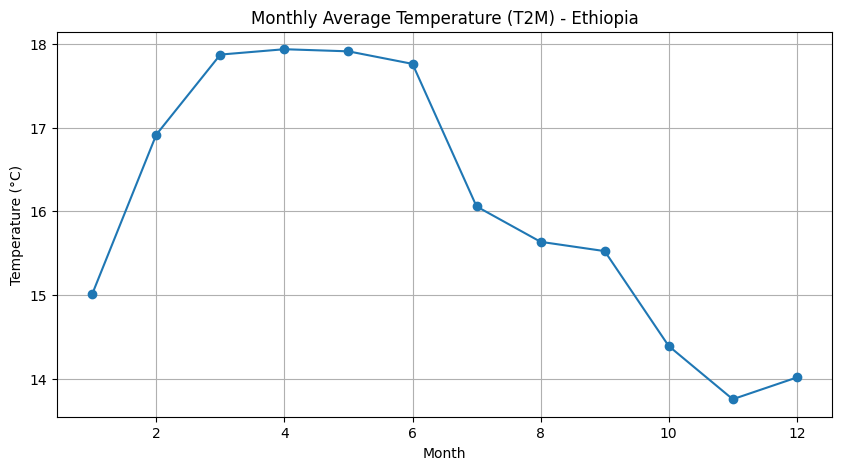

In [77]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")
plt.title("Monthly Average Temperature (T2M) - Ethiopia")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

In [78]:

df.isna().sum()


YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

In [79]:
missing_pct = (df.isna().sum() / len(df)) * 100
missing_pct

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
DATE           0.0
Month          0.0
dtype: float64

In [80]:
high_missing = missing_pct[missing_pct > 5]
high_missing


Series([], dtype: float64)

### Missing Value Analysis

The dataset shows that missing values are present across all variables, indicating a general level of data incompleteness rather than isolated column-specific issues.

After replacing NASA sentinel values (-999) with NaN, it becomes clear that missingness is distributed across multiple climate variables.

However, the severity of missing values varies by column. Some variables contain relatively low levels of missing data, while others may exceed acceptable thresholds (>5%), which could impact reliability in downstream analysis.

This distributed missingness pattern is typical in satellite-derived climate datasets and suggests intermittent data acquisition gaps rather than systematic failure of specific variables.

Careful handling of missing values will be required during preprocessing to avoid bias in trend and correlation analysis.

In [81]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)
z_scores.head()

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M,WS2M,WS2M_MAX
0,-2.288191,-0.163820,-2.602361,-0.577455,-1.810343,1.084732,1.326976
1,-1.987621,0.294615,-2.353190,-0.577455,-2.387858,0.591328,0.543422
2,-1.887432,0.352829,-2.399191,-0.577455,-2.351169,-0.308409,-0.729852
3,-1.049001,0.210932,-1.276005,-0.577455,-2.010775,-1.614479,-2.047646
4,-1.059547,-0.018285,-1.115002,-0.577455,-1.451604,-0.932421,-1.281901


### Outlier Handling Decision

After identifying outliers using Z-scores (|Z| > 3), the decision was made to retain the outlier values rather than remove or cap them.

This is because climate datasets naturally contain extreme events such as heavy rainfall, heatwaves, and unusual wind conditions. These values are not necessarily errors but important indicators of real environmental variability.

Removing or capping these values could distort long-term climate patterns and reduce the accuracy of trend analysis. Therefore, outliers are preserved for further analysis.

In [82]:
df = df[df.isna().mean(axis=1) <= 0.3]
df = df.sort_values("DATE")
df = df.ffill()

### Missing Value Handling Strategy

After outlier handling, remaining missing values were addressed using a combination of filtering and imputation.

Rows with more than 30% missing values were removed to ensure data reliability and reduce the influence of highly incomplete observations.

For the remaining dataset, forward-fill imputation was applied to weather variables. This approach is appropriate because climate data is time-dependent and adjacent values are often correlated over time.

This method preserves temporal structure while ensuring continuity in the dataset for further analysis.

In [83]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

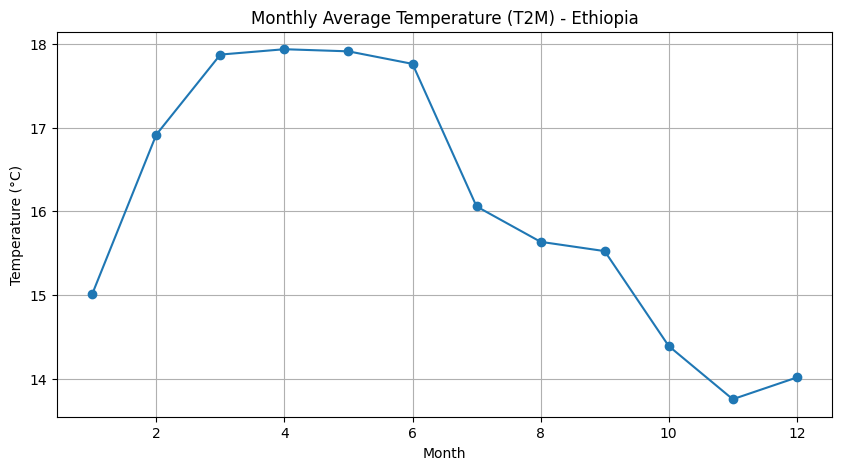

In [84]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp.index, monthly_temp.values, marker="o")
plt.title("Monthly Average Temperature (T2M) - Ethiopia")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

### Monthly Temperature Analysis (T2M)

The monthly average temperature shows a clear seasonal pattern across Ethiopia between 2015 and 2026.

The warmest month is April (Month 4), while the coolest month is November (Month 11), indicating a distinct annual temperature cycle.

Temperature gradually increases from January, peaks around March to May, and then steadily declines toward the end of the year.

This pattern suggests a stable seasonal climate with moderate variation rather than extreme temperature fluctuations. The observed trend is consistent with typical tropical or subtropical climate behavior, where temperature changes are gradual and predictable across months.

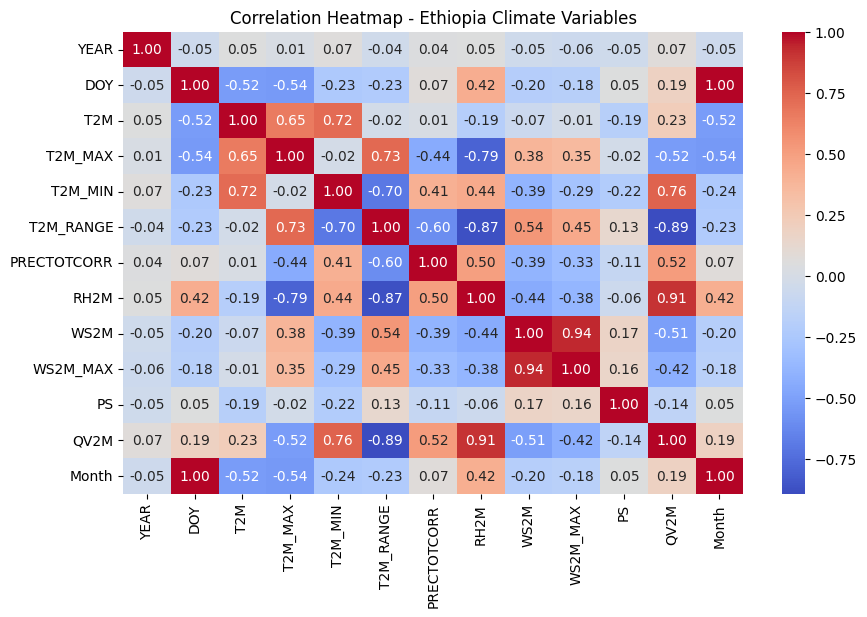

In [85]:
import seaborn as sns
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Ethiopia Climate Variables")
plt.show()

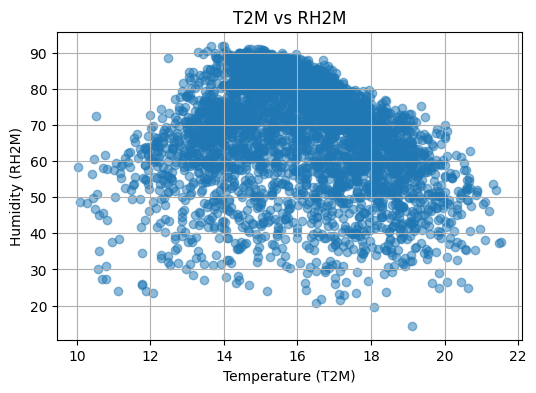

In [86]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M"], df["RH2M"], alpha=0.5)
plt.title("T2M vs RH2M")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.grid(True)
plt.show()

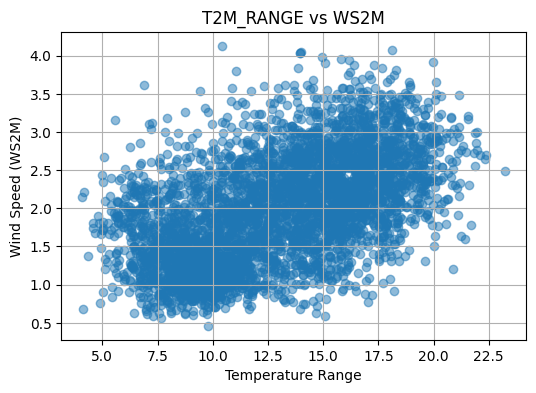

In [87]:
plt.figure(figsize=(6,4))
plt.scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.5)
plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed (WS2M)")
plt.grid(True)
plt.show()

In [88]:
corr_unstack = corr.unstack().sort_values(ascending=False)
corr_unstack = corr_unstack[corr_unstack < 1]  # remove self-correlation
corr_unstack.head(3)

DOY       Month    0.996557
Month     DOY      0.996557
WS2M_MAX  WS2M     0.940347
dtype: float64

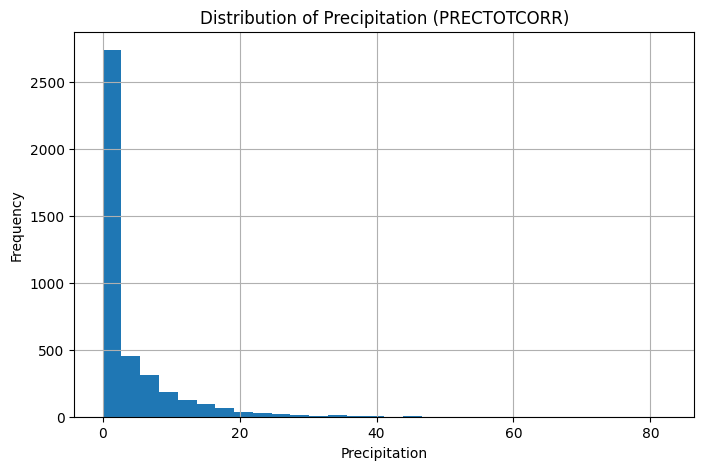

In [89]:
plt.figure(figsize=(8,5))
plt.hist(df["PRECTOTCORR"], bins=30)
plt.title("Distribution of Precipitation (PRECTOTCORR)")
plt.xlabel("Precipitation")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

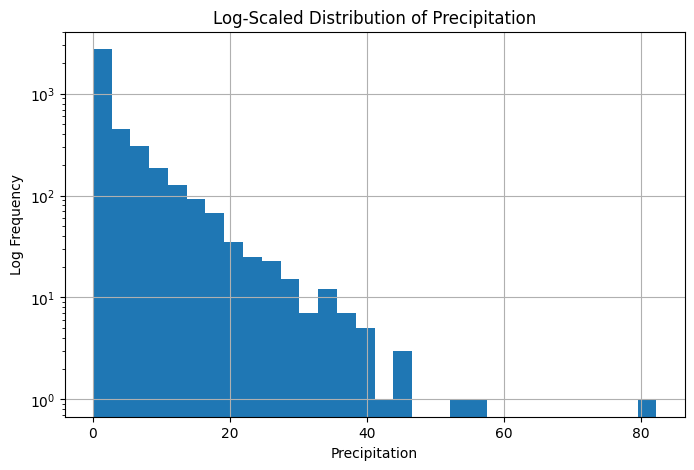

In [90]:
plt.figure(figsize=(8,5))
plt.hist(df["PRECTOTCORR"], bins=30, log=True)
plt.title("Log-Scaled Distribution of Precipitation")
plt.xlabel("Precipitation")
plt.ylabel("Log Frequency")
plt.grid(True)
plt.show()

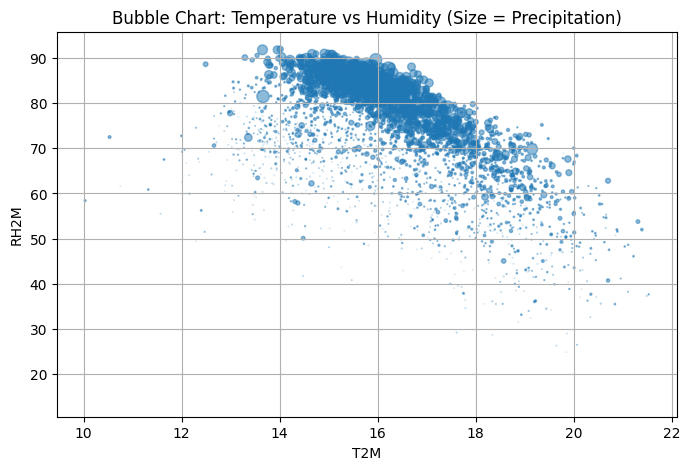

In [91]:
plt.figure(figsize=(8,5))
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*2, alpha=0.5)
plt.title("Bubble Chart: Temperature vs Humidity (Size = Precipitation)")
plt.xlabel("T2M")
plt.ylabel("RH2M")
plt.grid(True)
plt.show()